# Icequake TTNS — Classical XGBoost baseline + bimodal comparison figure

Trimmed down to the minimum needed to reproduce the bimodal "True vs. Predicted"
comparison figure (unconstrained XGBoost vs. classifier-gated XGBoost).

**Variable naming convention used throughout this notebook** (to avoid the
overwrite bug from the original file):
- Every model, prediction, and derived array is named for exactly what it is,
  once, and is never reassigned anywhere else in the notebook.
- `y_pred_classical`   → predictions from the single unconstrained XGBoost regressor
- `y_pred_constrained` → predictions from the classifier-gated (short/long) pipeline
- Nothing named `XG_pred_secs`, `XGBoost_Prediction`, or similar generic names
  is reused — those are exactly what caused the last figure to render two
  identical panels.

## 1. Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, accuracy_score
from sklearn.utils.class_weight import compute_sample_weight
from xgboost import XGBRegressor, XGBClassifier
import optuna

from Preprocess import preprocess_data_window

c:\Users\kaitl\anaconda3\envs\icequake-qrc\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Load data and build the windowed feature set

In [2]:
data_orig = pd.read_csv("../Whillians-GPS-Data-and-Features.csv")
filtered_time = pd.read_csv("../filtered_time_to_next_event.csv")

n = int(len(filtered_time) * 0.5)
filtered_time = filtered_time.iloc[:n]
data_orig = data_orig.iloc[:n]

N_PREVIOUS_EVENTS = 20
SHORT_THRESHOLD = 65_000  # seconds — boundary between short and long TTNS classes

X_train, X_val, X_test, y_train, y_val, y_test, feature_cols = preprocess_data_window(
    filtered_time, data_orig, N_PREVIOUS_EVENTS
)

# Numpy views used by the constrained pipeline below
y_train_np = y_train.to_numpy() if hasattr(y_train, "to_numpy") else np.array(y_train)
y_val_np   = y_val.to_numpy()   if hasattr(y_val,   "to_numpy") else np.array(y_val)
y_test_np  = y_test.to_numpy()  if hasattr(y_test,  "to_numpy") else np.array(y_test)

X_train_np = X_train.to_numpy() if hasattr(X_train, "to_numpy") else np.array(X_train)
X_val_np   = X_val.to_numpy()   if hasattr(X_val,   "to_numpy") else np.array(X_val)
X_test_np  = X_test.to_numpy()  if hasattr(X_test,  "to_numpy") else np.array(X_test)

print(f"Features used: {[c.split('-')[0] for c in feature_cols]}")
print(f"Train / val / test sizes: {len(y_train)} / {len(y_val)} / {len(y_test)}")

X shape:  (1411, 126)
y shape:  (1411,)
Features used: ['tide_deriv', 'form_fac', 'time_since', 'slip_size', 'high_t_evt', 'tide_height']
Train / val / test sizes: 846 / 282 / 283


## 3. Classical baseline — single unconstrained XGBoost regressor

This is the "Good XGBoost" model: one regressor trained on the full range of
TTNS values, no classifier gating.

In [3]:
def classical_objective(trial):
    model = XGBRegressor(
        objective="reg:squarederror",
        n_estimators=1000,
        learning_rate=trial.suggest_float("learning_rate", 0.01, 0.1, log=True),
        max_depth=trial.suggest_int("max_depth", 2, 5),
        subsample=trial.suggest_float("subsample", 0.6, 0.9),
        colsample_bytree=trial.suggest_float("colsample_bytree", 0.6, 0.9),
        random_state=42,
    )
    model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
    preds = model.predict(X_val)
    return root_mean_squared_error(y_val, preds)

classical_study = optuna.create_study(
    direction="minimize", sampler=optuna.samplers.TPESampler(seed=42)
)
classical_study.optimize(classical_objective, n_trials=30)
classical_best_params = classical_study.best_params
print("Classical XGBoost — optimal parameters:", classical_best_params)

xgb_classical_model = XGBRegressor(
    objective="reg:squarederror",
    n_estimators=1000,
    **classical_best_params,
    random_state=42,
)
xgb_classical_model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)

# ── Predictions from the classical model — this name is never reused ──
y_pred_classical = xgb_classical_model.predict(X_test)

classical_mae  = mean_absolute_error(y_test, y_pred_classical)
classical_rmse = root_mean_squared_error(y_test, y_pred_classical)
print(f"Classical XGBoost — Test MAE:  {classical_mae:.2f}s")
print(f"Classical XGBoost — Test RMSE: {classical_rmse:.2f}s")

[I 2026-07-25 21:10:13,088] A new study created in memory with name: no-name-f6b57c11-4d20-4a8a-8e64-0d9a0454ace6
[I 2026-07-25 21:10:16,243] Trial 0 finished with value: 14915.322345160464 and parameters: {'learning_rate': 0.023688639503640783, 'max_depth': 5, 'subsample': 0.8195981825434215, 'colsample_bytree': 0.779597545259111}. Best is trial 0 with value: 14915.322345160464.
[I 2026-07-25 21:10:17,407] Trial 1 finished with value: 15751.122504234863 and parameters: {'learning_rate': 0.014322493718230255, 'max_depth': 2, 'subsample': 0.6174250836504598, 'colsample_bytree': 0.8598528437324806}. Best is trial 0 with value: 14915.322345160464.
[I 2026-07-25 21:10:20,212] Trial 2 finished with value: 15133.21143669353 and parameters: {'learning_rate': 0.039913058785616795, 'max_depth': 4, 'subsample': 0.6061753482887408, 'colsample_bytree': 0.8909729556485984}. Best is trial 0 with value: 14915.322345160464.
[I 2026-07-25 21:10:21,856] Trial 3 finished with value: 15626.720311608511 an

Classical XGBoost — optimal parameters: {'learning_rate': 0.02339854206689045, 'max_depth': 5, 'subsample': 0.7887985998089446, 'colsample_bytree': 0.760314536995455}
Classical XGBoost — Test MAE:  12013.61s
Classical XGBoost — Test RMSE: 16050.37s


## 4. Constrained pipeline — classifier-gated short/long regressors

A classifier first routes each event to a "short" or "long" TTNS regime,
then a dedicated regressor (trained only on that regime) makes the prediction.

In [4]:
# ── 4a. Classifier: short (< threshold) vs long (>= threshold) ──
y_clf_train = (y_train >= SHORT_THRESHOLD).astype(int)
y_clf_val   = (y_val   >= SHORT_THRESHOLD).astype(int)
sample_weights_train = compute_sample_weight("balanced", y_clf_train)

def clf_objective(trial):
    clf = XGBClassifier(
        objective="binary:logistic",
        n_estimators=500,
        learning_rate=trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
        max_depth=trial.suggest_int("max_depth", 2, 6),
        subsample=trial.suggest_float("subsample", 0.6, 0.9),
        colsample_bytree=trial.suggest_float("colsample_bytree", 0.6, 0.9),
        scale_pos_weight=trial.suggest_float("scale_pos_weight", 0.5, 3.0),
        random_state=42,
        eval_metric="logloss",
    )
    clf.fit(
        X_train, y_clf_train,
        sample_weight=sample_weights_train,
        eval_set=[(X_val, y_clf_val)],
        verbose=False,
    )
    preds = clf.predict(X_val)
    return 1.0 - accuracy_score(y_clf_val, preds)

clf_study = optuna.create_study(
    direction="minimize", sampler=optuna.samplers.TPESampler(seed=42)
)
clf_study.optimize(clf_objective, n_trials=30)
clf_best_params = clf_study.best_params
print("Classifier — optimal parameters:", clf_best_params)

event_regime_classifier = XGBClassifier(
    objective="binary:logistic",
    n_estimators=500,
    **clf_best_params,
    random_state=42,
    eval_metric="logloss",
)
event_regime_classifier.fit(
    X_train, y_clf_train,
    sample_weight=sample_weights_train,
    eval_set=[(X_val, y_clf_val)],
    verbose=False,
)

clf_test_labels = event_regime_classifier.predict(X_test_np)
true_clf_labels = (y_test_np >= SHORT_THRESHOLD).astype(int)
print(f"Classifier routing accuracy: {accuracy_score(true_clf_labels, clf_test_labels):.4f}")

[I 2026-07-25 21:11:31,947] A new study created in memory with name: no-name-3be8643e-a420-4884-86c5-b60f53032e36
[I 2026-07-25 21:11:33,632] Trial 0 finished with value: 0.15957446808510634 and parameters: {'learning_rate': 0.030710573677773714, 'max_depth': 6, 'subsample': 0.8195981825434215, 'colsample_bytree': 0.779597545259111, 'scale_pos_weight': 0.8900466011060912}. Best is trial 0 with value: 0.15957446808510634.
[I 2026-07-25 21:11:34,339] Trial 1 finished with value: 0.2978723404255319 and parameters: {'learning_rate': 0.015957084694148364, 'max_depth': 2, 'subsample': 0.8598528437324806, 'colsample_bytree': 0.7803345035229626, 'scale_pos_weight': 2.2701814444901136}. Best is trial 0 with value: 0.15957446808510634.
[I 2026-07-25 21:11:36,225] Trial 2 finished with value: 0.14893617021276595 and parameters: {'learning_rate': 0.010636066512540286, 'max_depth': 6, 'subsample': 0.8497327922401265, 'colsample_bytree': 0.6637017332034828, 'scale_pos_weight': 0.9545624180177515}. B

Classifier — optimal parameters: {'learning_rate': 0.010636066512540286, 'max_depth': 6, 'subsample': 0.8497327922401265, 'colsample_bytree': 0.6637017332034828, 'scale_pos_weight': 0.9545624180177515}
Classifier routing accuracy: 0.8269


In [5]:
# ── 4b. Short and long sub-regressors ──
SHORT_LOWER, SHORT_UPPER = 25_000, 65_000
LONG_LOWER,  LONG_UPPER  = 65_000, 100_000

short_mask_train = y_train_np < SHORT_THRESHOLD
long_mask_train  = ~short_mask_train
short_mask_val   = y_val_np   < SHORT_THRESHOLD
long_mask_val    = ~short_mask_val

X_tr_short, y_tr_short = X_train_np[short_mask_train], y_train_np[short_mask_train]
X_vl_short, y_vl_short = X_val_np[short_mask_val],     y_val_np[short_mask_val]
X_tr_long,  y_tr_long  = X_train_np[long_mask_train],  y_train_np[long_mask_train]
X_vl_long,  y_vl_long  = X_val_np[long_mask_val],      y_val_np[long_mask_val]

def short_objective(trial):
    model = XGBRegressor(
        objective="reg:squarederror",
        n_estimators=1000,
        learning_rate=trial.suggest_float("learning_rate", 0.01, 0.1, log=True),
        max_depth=trial.suggest_int("max_depth", 2, 5),
        subsample=trial.suggest_float("subsample", 0.6, 0.9),
        colsample_bytree=trial.suggest_float("colsample_bytree", 0.6, 0.9),
        random_state=42,
    )
    model.fit(X_tr_short, y_tr_short, eval_set=[(X_vl_short, y_vl_short)], verbose=False)
    preds = np.clip(model.predict(X_vl_short), SHORT_LOWER, SHORT_UPPER)
    return root_mean_squared_error(y_vl_short, preds)

def long_objective(trial):
    model = XGBRegressor(
        objective="reg:squarederror",
        n_estimators=1000,
        learning_rate=trial.suggest_float("learning_rate", 0.01, 0.1, log=True),
        max_depth=trial.suggest_int("max_depth", 2, 5),
        subsample=trial.suggest_float("subsample", 0.6, 0.9),
        colsample_bytree=trial.suggest_float("colsample_bytree", 0.6, 0.9),
        random_state=42,
    )
    model.fit(X_tr_long, y_tr_long, eval_set=[(X_vl_long, y_vl_long)], verbose=False)
    preds = np.clip(model.predict(X_vl_long), LONG_LOWER, LONG_UPPER)
    return root_mean_squared_error(y_vl_long, preds)

opt_short = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=42))
opt_short.optimize(short_objective, n_trials=30)

opt_long = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=42))
opt_long.optimize(long_objective, n_trials=30)

xgb_short_model = XGBRegressor(
    objective="reg:squarederror", n_estimators=1000, **opt_short.best_params, random_state=42
)
xgb_short_model.fit(X_tr_short, y_tr_short, eval_set=[(X_vl_short, y_vl_short)], verbose=False)

xgb_long_model = XGBRegressor(
    objective="reg:squarederror", n_estimators=1000, **opt_long.best_params, random_state=42
)
xgb_long_model.fit(X_tr_long, y_tr_long, eval_set=[(X_vl_long, y_vl_long)], verbose=False)

# ── 4c. Route test events through the classifier, predict with the matching regressor ──
# This name is never reused anywhere else in the notebook.
y_pred_constrained = np.empty(len(X_test_np))

short_idx = np.where(clf_test_labels == 0)[0]
long_idx  = np.where(clf_test_labels == 1)[0]

if len(short_idx) > 0:
    y_pred_constrained[short_idx] = xgb_short_model.predict(X_test_np[short_idx])
if len(long_idx) > 0:
    y_pred_constrained[long_idx] = xgb_long_model.predict(X_test_np[long_idx])

constrained_mae  = mean_absolute_error(y_test_np, y_pred_constrained)
constrained_rmse = root_mean_squared_error(y_test_np, y_pred_constrained)
print(f"Constrained pipeline — Test MAE:  {constrained_mae:.2f}s")
print(f"Constrained pipeline — Test RMSE: {constrained_rmse:.2f}s")

[I 2026-07-25 21:12:14,885] A new study created in memory with name: no-name-864e7065-2cee-4afb-a22d-740d93a65316
[I 2026-07-25 21:12:17,672] Trial 0 finished with value: 4701.820721678645 and parameters: {'learning_rate': 0.023688639503640783, 'max_depth': 5, 'subsample': 0.8195981825434215, 'colsample_bytree': 0.779597545259111}. Best is trial 0 with value: 4701.820721678645.
[I 2026-07-25 21:12:18,683] Trial 1 finished with value: 5000.10913706565 and parameters: {'learning_rate': 0.014322493718230255, 'max_depth': 2, 'subsample': 0.6174250836504598, 'colsample_bytree': 0.8598528437324806}. Best is trial 0 with value: 4701.820721678645.
[I 2026-07-25 21:12:20,355] Trial 2 finished with value: 4720.930155487966 and parameters: {'learning_rate': 0.039913058785616795, 'max_depth': 4, 'subsample': 0.6061753482887408, 'colsample_bytree': 0.8909729556485984}. Best is trial 0 with value: 4701.820721678645.
[I 2026-07-25 21:12:20,981] Trial 3 finished with value: 5155.87672904873 and parame

Constrained pipeline — Test MAE:  9696.93s
Constrained pipeline — Test RMSE: 18189.52s


## 5. Bimodal comparison figure

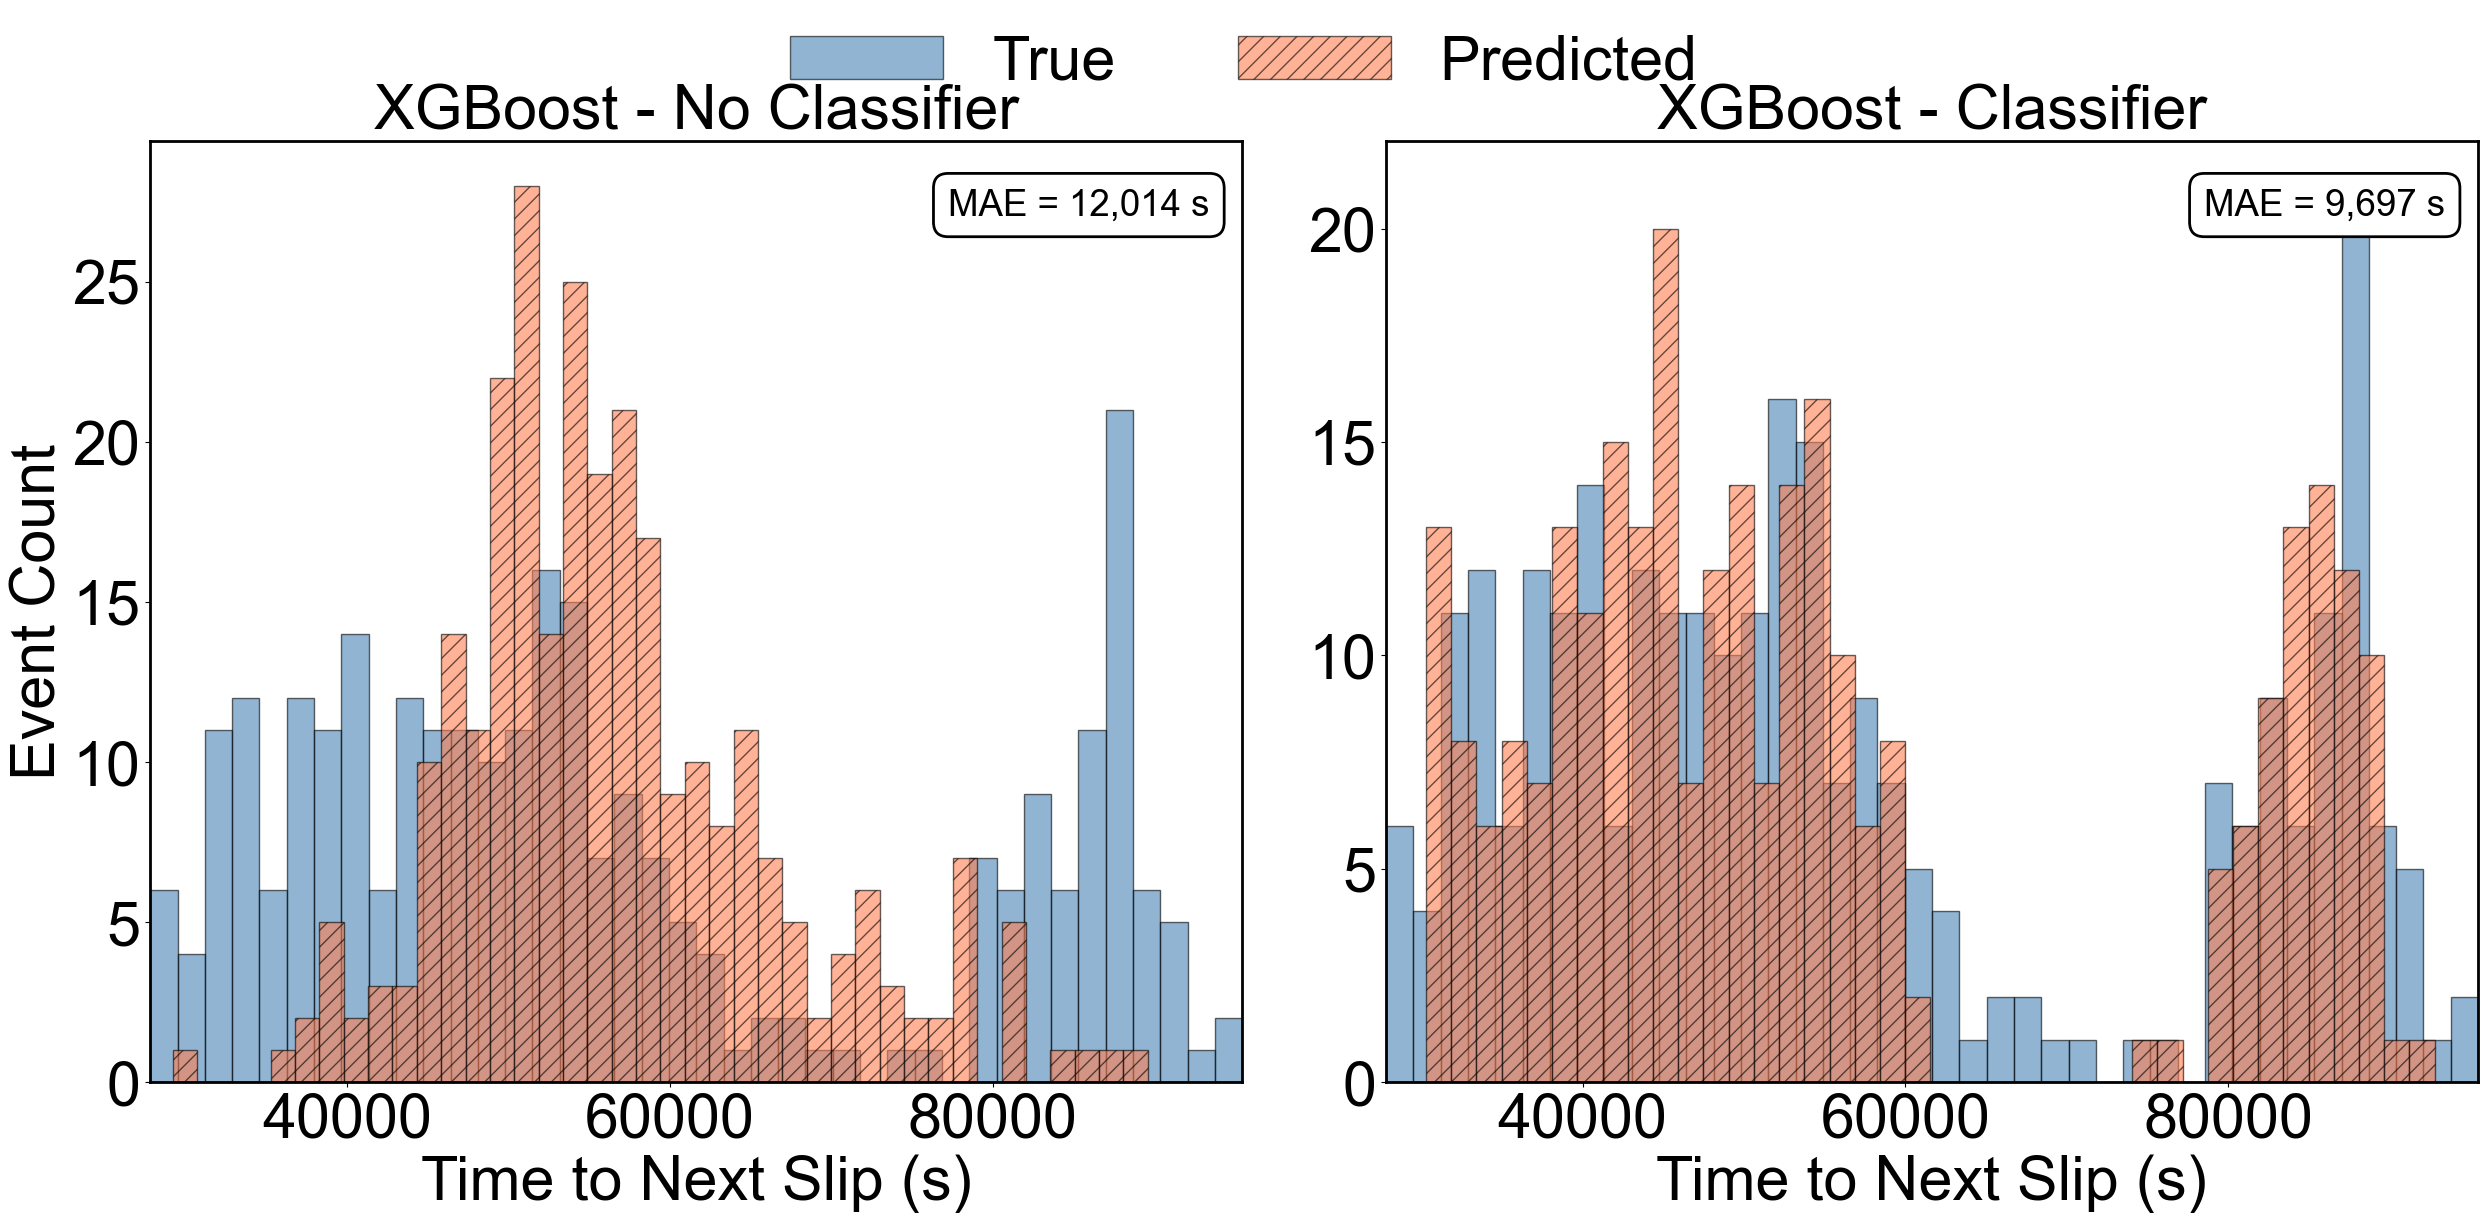

In [6]:
FONT_SIZE = 44

plt.rcParams.update({
    "font.family": "Arial",
    "font.size": FONT_SIZE,
    "axes.labelsize": FONT_SIZE,
    "axes.titlesize": FONT_SIZE,
    "xtick.labelsize": FONT_SIZE,
    "ytick.labelsize": FONT_SIZE,
    "legend.fontsize": FONT_SIZE,
    "axes.linewidth": 2,
    "axes.edgecolor": "black",
    "axes.grid": False,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "legend.frameon": False,
})

def style_axes(ax):
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(2)
        spine.set_color('black')
    ax.grid(False)

# Sized up substantially from the original so 44pt text has room to breathe —
# adjust to taste for the poster panel it's going into.
fig, axes = plt.subplots(1, 2, figsize=(26, 13))

# ── Panel A: classical (unconstrained) XGBoost ──
axes[0].hist(y_test_np, bins=40, alpha=0.6, color='steelblue',
             label='True', edgecolor='black')
axes[0].hist(y_pred_classical, bins=40, alpha=0.6, color='coral',
             label='Predicted', edgecolor='black', hatch='//')
axes[0].set_xlabel("Time to Next Slip (s)")
axes[0].set_ylabel("Event Count")
axes[0].set_title("XGBoost - No Classifier")
style_axes(axes[0])

# ── Panel B: classifier-gated (constrained) XGBoost ──
axes[1].hist(y_test_np, bins=40, alpha=0.6, color='steelblue',
             label='True', edgecolor='black')
axes[1].hist(y_pred_constrained, bins=40, alpha=0.6, color='coral',
             label='Predicted', edgecolor='black', hatch='//')
axes[1].set_xlabel("Time to Next Slip (s)")
axes[1].set_title("XGBoost - Classifier")
style_axes(axes[1])

# ── MAE annotation box in each panel ──
# Uses classical_mae / constrained_mae computed back in sections 3 and 4.
mae_box_style = dict(boxstyle='round,pad=0.4', facecolor='white',
                      edgecolor='black', linewidth=2)

axes[0].text(
    0.97, 0.95, f"MAE = {classical_mae:,.0f} s",
    transform=axes[0].transAxes, ha='right', va='top',
    fontsize=FONT_SIZE * 0.6, bbox=mae_box_style,
)
axes[1].text(
    0.97, 0.95, f"MAE = {constrained_mae:,.0f} s",
    transform=axes[1].transAxes, ha='right', va='top',
    fontsize=FONT_SIZE * 0.6, bbox=mae_box_style,
)

# ── Shared legend, pulled in tight against the panels ──
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles, labels,
    loc='upper center', bbox_to_anchor=(0.5, 1.0), ncol=2,
    handlelength=2.5, handletextpad=0.8, columnspacing=2.0,
)

# Shared x-axis limits across both panels
xmin = min(y_test_np.min(), y_pred_classical.min(), y_pred_constrained.min())
xmax = max(y_test_np.max(), y_pred_classical.max(), y_pred_constrained.max())
for ax in axes:
    ax.set_xlim(xmin, xmax)

# rect top trimmed close to 1.0 since the legend now sits just above the axes
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig("figure_bimodal_doublepanel.svg", bbox_inches='tight')
plt.savefig("figure_bimodal_doublepanel.png", dpi=600, bbox_inches='tight')
plt.show()

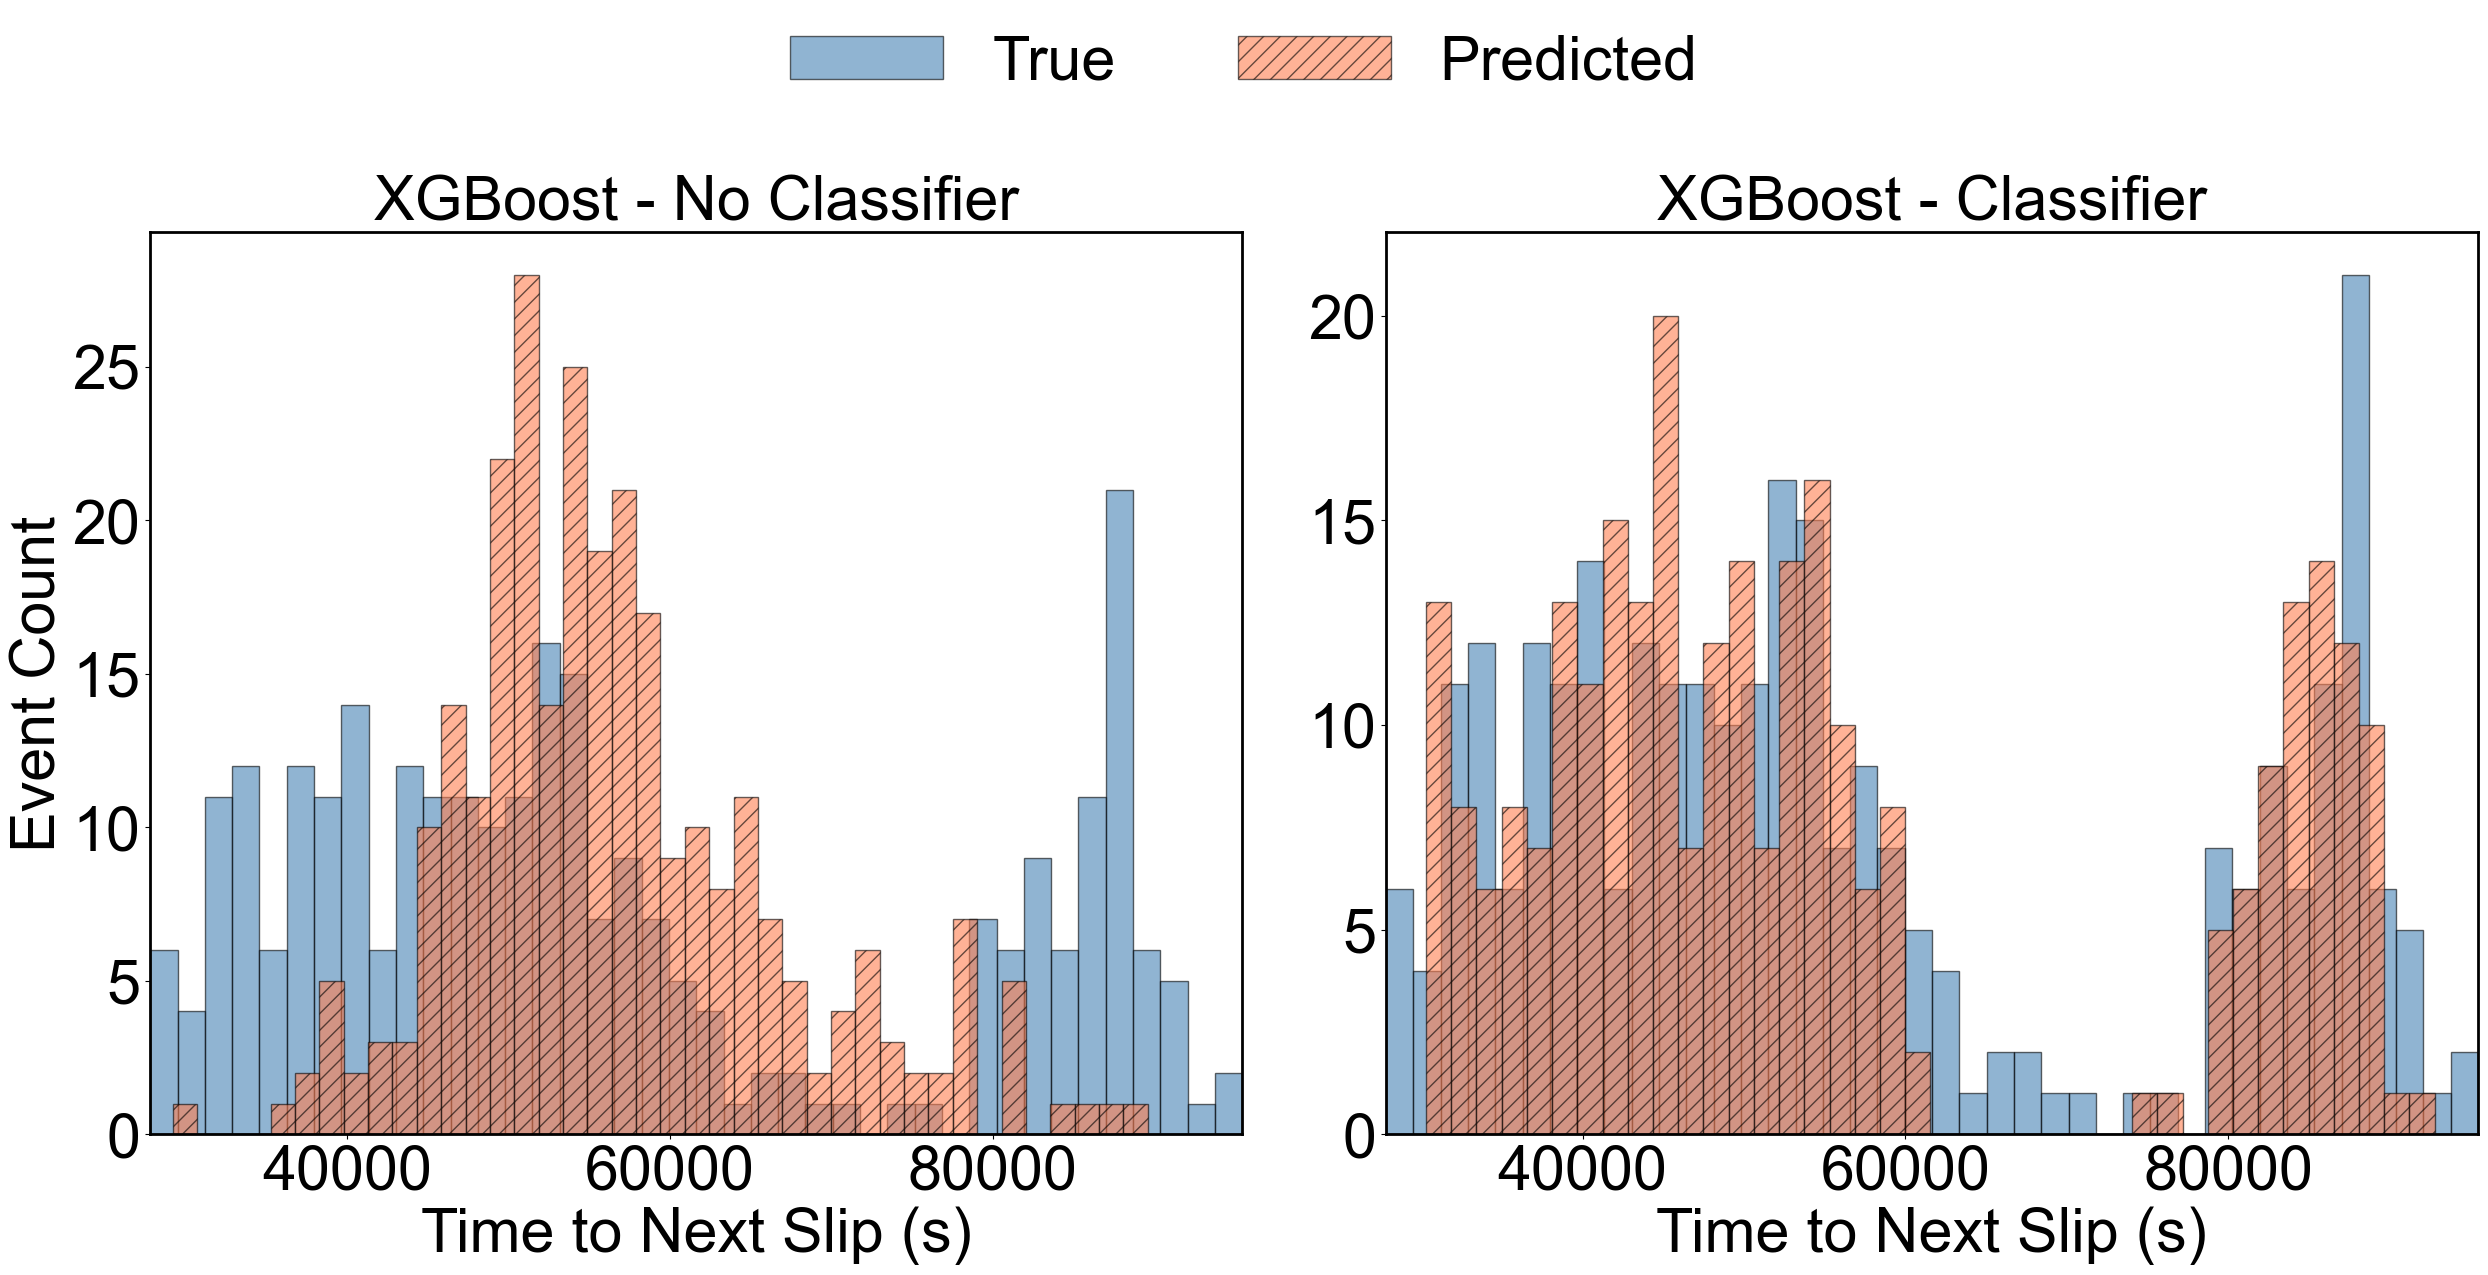

In [8]:
FONT_SIZE = 44

plt.rcParams.update({
    "font.family": "Arial",
    "font.size": FONT_SIZE,
    "axes.labelsize": FONT_SIZE,
    "axes.titlesize": FONT_SIZE,
    "xtick.labelsize": FONT_SIZE,
    "ytick.labelsize": FONT_SIZE,
    "legend.fontsize": FONT_SIZE,
    "axes.linewidth": 2,
    "axes.edgecolor": "black",
    "axes.grid": False,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "legend.frameon": False,
})

def style_axes(ax):
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(2)
        spine.set_color('black')
    ax.grid(False)

fig, axes = plt.subplots(1, 2, figsize=(26, 13))

# ── Panel A: classical (unconstrained) XGBoost ──
axes[0].hist(y_test_np, bins=40, alpha=0.6, color='steelblue',
             label='True', edgecolor='black')
axes[0].hist(y_pred_classical, bins=40, alpha=0.6, color='coral',
             label='Predicted', edgecolor='black', hatch='//')
axes[0].set_xlabel("Time to Next Slip (s)")
axes[0].set_ylabel("Event Count")
axes[0].set_title("XGBoost - No Classifier")
style_axes(axes[0])

# ── Panel B: classifier-gated (constrained) XGBoost ──
axes[1].hist(y_test_np, bins=40, alpha=0.6, color='steelblue',
             label='True', edgecolor='black')
axes[1].hist(y_pred_constrained, bins=40, alpha=0.6, color='coral',
             label='Predicted', edgecolor='black', hatch='//')
axes[1].set_xlabel("Time to Next Slip (s)")
axes[1].set_title("XGBoost - Classifier")
style_axes(axes[1])

# ── Shared legend — a touch further from the panels than the tightest version ──
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles, labels,
    loc='upper center', bbox_to_anchor=(0.5, 1.04), ncol=2,
    handlelength=2.5, handletextpad=0.8, columnspacing=2.0,
)

# Shared x-axis limits across both panels
xmin = min(y_test_np.min(), y_pred_classical.min(), y_pred_constrained.min())
xmax = max(y_test_np.max(), y_pred_classical.max(), y_pred_constrained.max())
for ax in axes:
    ax.set_xlim(xmin, xmax)

plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.savefig("the_bimodal.svg", bbox_inches='tight')
plt.savefig("figure_bimodal_doublepanel_no_mae_box.png", dpi=600, bbox_inches='tight')
plt.show()

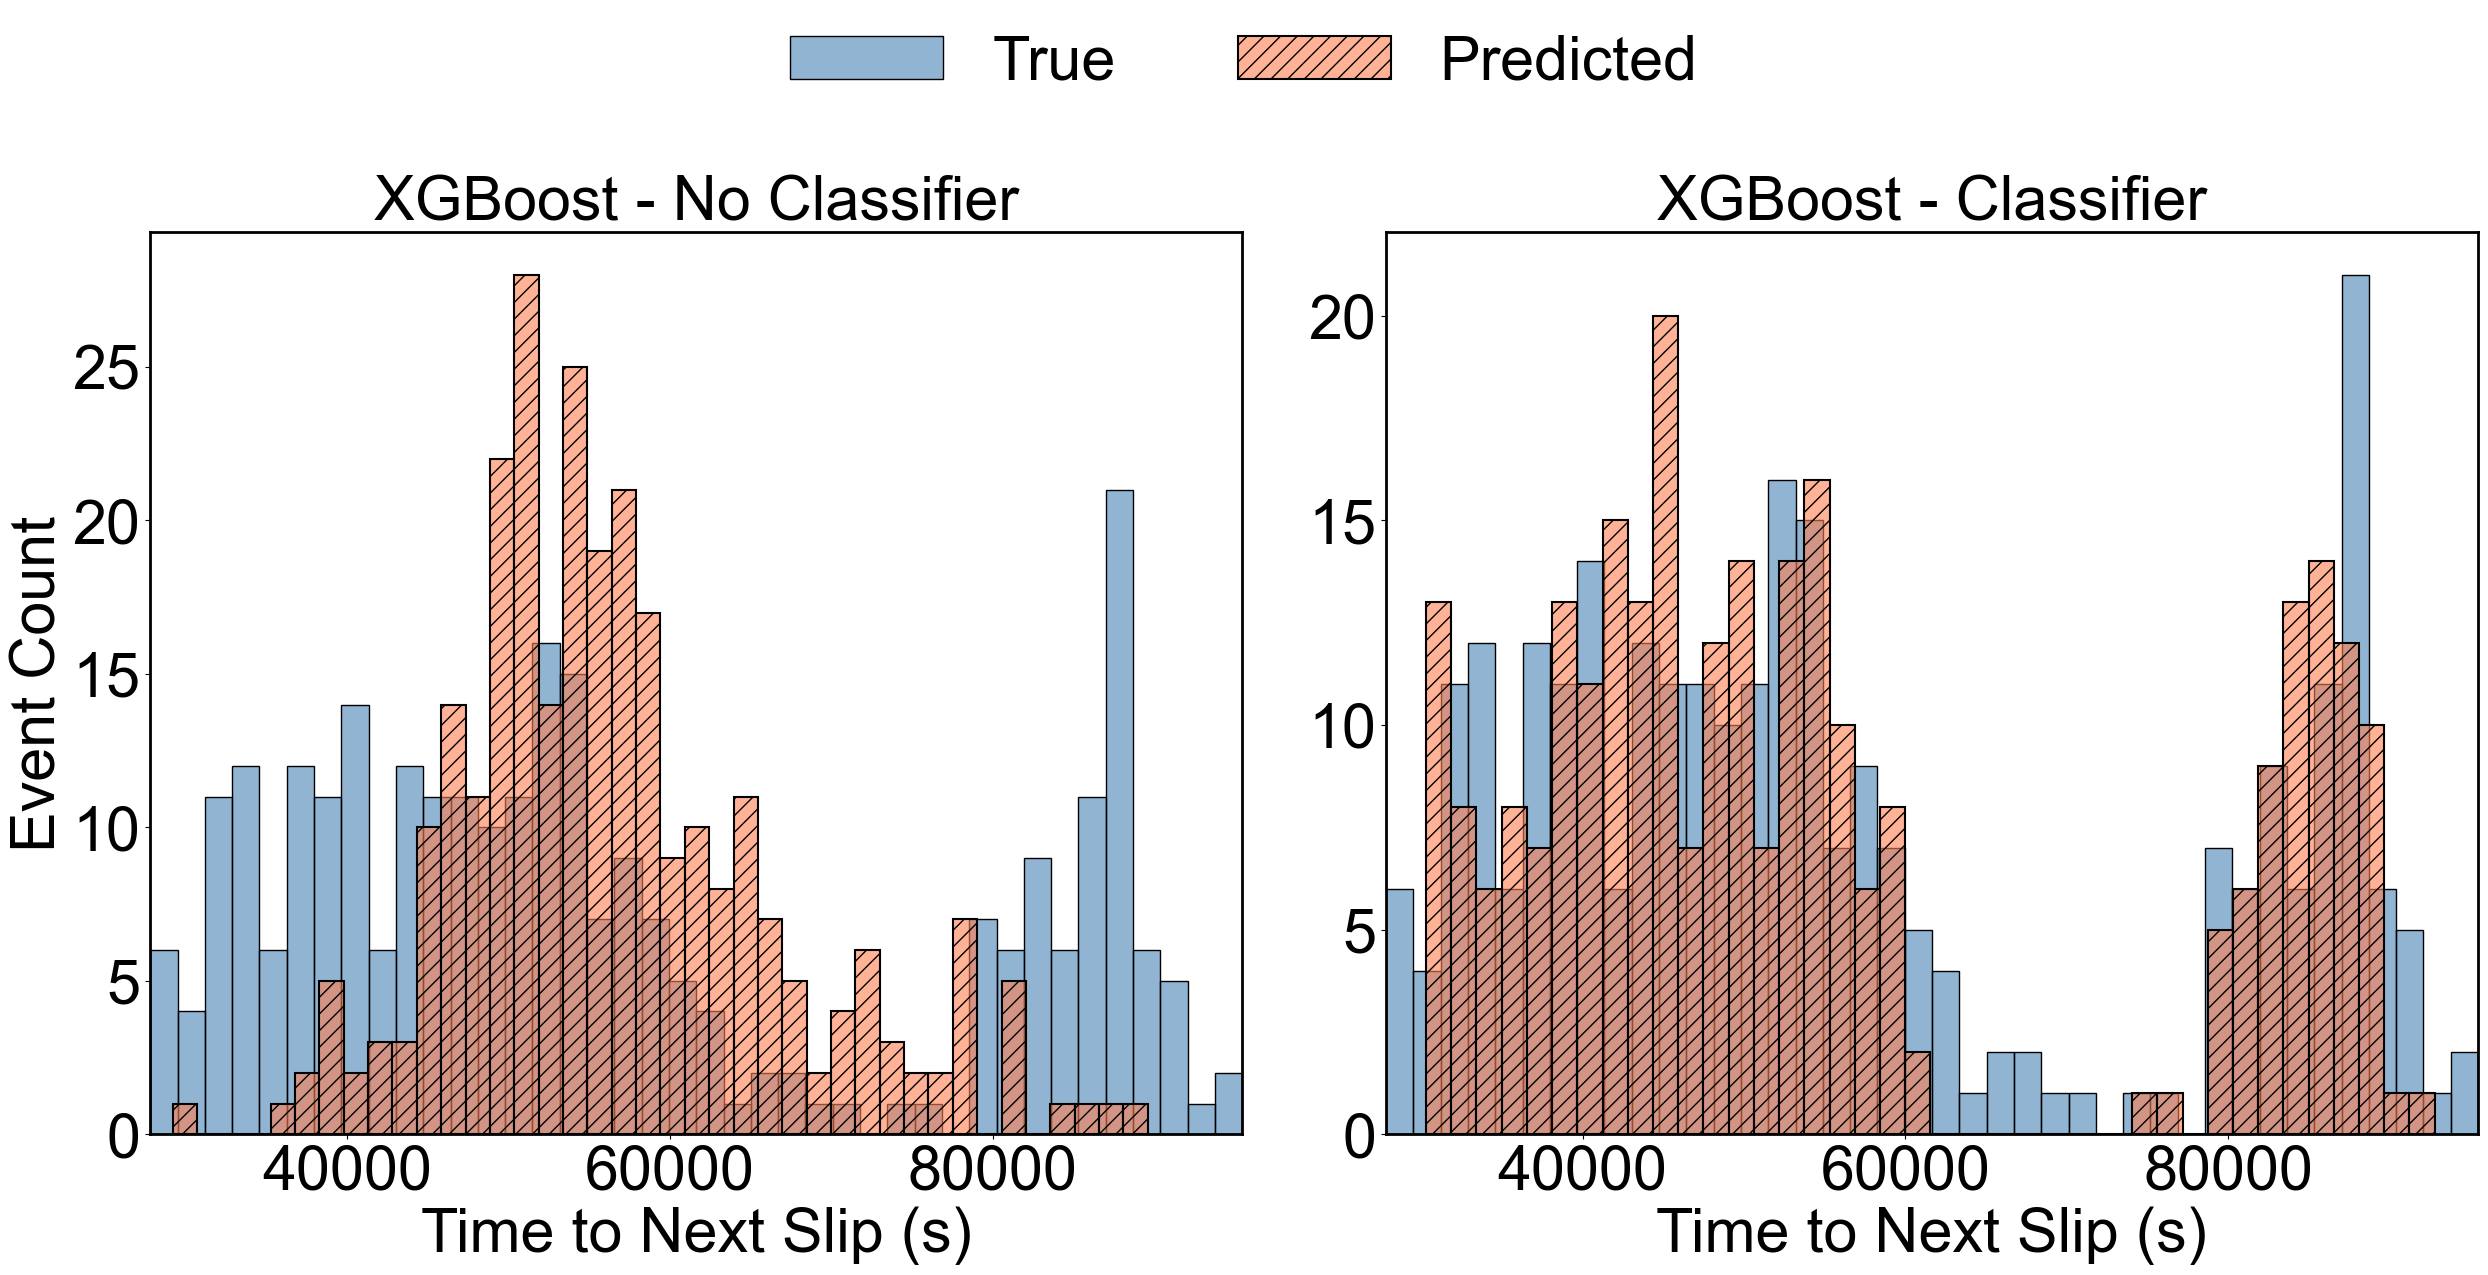

In [11]:
FONT_SIZE = 44

plt.rcParams.update({
    "font.family": "Arial",
    "font.size": FONT_SIZE,
    "axes.labelsize": FONT_SIZE,
    "axes.titlesize": FONT_SIZE,
    "xtick.labelsize": FONT_SIZE,
    "ytick.labelsize": FONT_SIZE,
    "legend.fontsize": FONT_SIZE,
    "axes.linewidth": 2,
    "axes.edgecolor": "black",
    "axes.grid": False,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "legend.frameon": False,
})

def style_axes(ax):
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(2)
        spine.set_color('black')
    ax.grid(False)

# Translucent fill colors as RGBA — alpha baked in here so it does NOT
# also fade the hatch lines (which happens if you pass alpha= to hist()
# directly instead).
from matplotlib.colors import to_rgba
true_color      = to_rgba('steelblue', alpha=0.6)
predicted_color = to_rgba('coral', alpha=0.6)

fig, axes = plt.subplots(1, 2, figsize=(26, 13))

# ── Panel A: classical (unconstrained) XGBoost ──
axes[0].hist(y_test_np, bins=40, color=true_color,
             label='True', edgecolor='black')
axes[0].hist(y_pred_classical, bins=40, color=predicted_color,
             label='Predicted', edgecolor='black', hatch='//', linewidth=1.5)
axes[0].set_xlabel("Time to Next Slip (s)")
axes[0].set_ylabel("Event Count")
axes[0].set_title("XGBoost - No Classifier")
style_axes(axes[0])

# ── Panel B: classifier-gated (constrained) XGBoost ──
axes[1].hist(y_test_np, bins=40, color=true_color,
             label='True', edgecolor='black')
axes[1].hist(y_pred_constrained, bins=40, color=predicted_color,
             label='Predicted', edgecolor='black', hatch='//', linewidth=1.5)
axes[1].set_xlabel("Time to Next Slip (s)")
axes[1].set_title("XGBoost - Classifier")
style_axes(axes[1])

# ── Shared legend — a touch further from the panels than the tightest version ──
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles, labels,
    loc='upper center', bbox_to_anchor=(0.5, 1.04), ncol=2,
    handlelength=2.5, handletextpad=0.8, columnspacing=2.0,
)

# Shared x-axis limits across both panels
xmin = min(y_test_np.min(), y_pred_classical.min(), y_pred_constrained.min())
xmax = max(y_test_np.max(), y_pred_classical.max(), y_pred_constrained.max())
for ax in axes:
    ax.set_xlim(xmin, xmax)

plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.savefig("fr-bimodal.svg", bbox_inches='tight')
plt.savefig("fr.png", dpi=900, bbox_inches='tight')
plt.show()